# 03 · Modelo 2 — Matching candidato↔vacante con TF-IDF + Cosine (IR)

**Objetivo del TFG:** construir un emparejamiento candidato–vacante por *Information Retrieval*
(TF-IDF + similitud coseno) y **contrastarlo con el scorer heurístico vivo** de MatchKey para ver
en qué coinciden, en qué difieren y dónde aporta valor el enfoque textual.

**Qué hace este notebook**
1. **Replica fielmente el scorer heurístico vivo** (offline, sin backend) y deja claro qué
   componentes intervienen de verdad.
2. Representa candidatos y vacantes con TF-IDF y calcula similitud coseno.
3. Compara rankings: **Spearman** + **acuerdo en top-k (k=5, k=10)**.
4. Analiza **dónde difieren** y **dónde aporta TF-IDF**.

**Entradas:** `data/clean/candidate_skills_clean.csv`, `data/clean/job_skills_clean.csv`,
`data/clean/vacantes_clean.csv`. **Salida:** `data/clean/model2_ranking_comparison.csv` + figuras.

## ⚠️ Honestidad: qué parte del heurístico entra de verdad en la comparación

El scorer vivo (`backend/app/routers/matching.py`) calcula
`global = round((skills_fit + values_fit + team_fit) / 3)` con:

- **`skills_fit` — REAL y variable.** Para las 236 vacantes sembradas la tabla `job_skills` de la BD
  está vacía, así que el backend usa como "nice-to-have" el conjunto `tech_stack ∪ soft_skills ∪ languages`
  (must vacío). Resulta `skills_fit = 70 + 30 · (|skills_candidato ∩ nice_vacante| / |nice_vacante|)`.
  **Es el único componente que varía** entre pares y, por tanto, **el que manda en el ranking**.
- **`values_fit` — STUB → CONSTANTE 60.** Depende de si el candidato tiene entrevista y de si la
  vacante tiene valores de equipo. Por el *seeding*: todos los candidatos del OCR tienen una
  `CandidateInterview`, y ninguna vacante sembrada tiene `team_profile` → `values_fit = 60` para todos.
- **`team_fit` — STUB → CONSTANTE 60.** Sin `team_profile`, `base = 55`; +5 por tener entrevista → `60`.

**Conclusión clave:** con estos datos, `values_fit` y `team_fit` son constantes y **no afectan al orden**.
El contraste de TF-IDF es, de facto, **contra `skills_fit` (overlap real de tags)**, NO contra un
matching de producción completo (cultura, equipo, etc. no están operativos). Lo verificamos abajo.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
ACCENT = "#A100FF"

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "data" / "clean").exists() or (p / "CLAUDE.md").exists():
            return p
        p = p.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
CLEAN = REPO_ROOT / "data" / "clean"
FIG = REPO_ROOT / "notebooks" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

cs = pd.read_csv(CLEAN / "candidate_skills_clean.csv")
js = pd.read_csv(CLEAN / "job_skills_clean.csv")
vac = pd.read_csv(CLEAN / "vacantes_clean.csv")
print("candidatos:", cs["candidate_id"].nunique(), "| vacantes:", vac["job_id"].nunique())

candidatos: 100 | vacantes: 236


## 1. Replicación fiel del scorer heurístico vivo (offline)

In [2]:
# Skills por candidato (conjunto normalizado)
cand_ids = sorted(cs["candidate_id"].unique())
cand_skills = {cid: set(g["skill_norm"]) for cid, g in cs.groupby("candidate_id")}

# "nice-to-have" por vacante = tech_stack ∪ soft_skill ∪ language (igual que el backend para jobs sembrados)
NICE_IMP = {"tech_stack", "soft_skill", "language"}
job_ids = sorted(vac["job_id"].unique())
job_nice = {jid: set(g.loc[g["importance"].isin(NICE_IMP), "skill_norm"])
            for jid, g in js.groupby("job_id")}
job_nice = {jid: job_nice.get(jid, set()) for jid in job_ids}

def skills_fit(cand_set, nice_set):
    # Réplica de compute_skills_fit (routers/matching.py) para el caso must=∅:
    #   must_ratio = 1.0 (must vacío); score = 100*(0.7*1.0 + 0.3*nice_ratio) = 70 + 30*nice_ratio
    if not nice_set:
        return 50  # el backend devuelve 50 si no hay info de skills
    nice_ratio = len(cand_set & nice_set) / len(nice_set)
    return int(round(100 * (0.7 * 1.0 + 0.3 * nice_ratio)))

VALUES_FIT_CONST = 60  # stub: todos con entrevista, vacantes sin team_profile
TEAM_FIT_CONST = 60    # stub: sin team_profile -> 55 + 5 (entrevista)

# Matriz heurística global[candidato, vacante]
H_skills = np.zeros((len(cand_ids), len(job_ids)))
for a, cid in enumerate(cand_ids):
    cset = cand_skills[cid]
    for b, jid in enumerate(job_ids):
        H_skills[a, b] = skills_fit(cset, job_nice[jid])
H_global = np.round((H_skills + VALUES_FIT_CONST + TEAM_FIT_CONST) / 3)

print("skills_fit -> rango:", int(H_skills.min()), "a", int(H_skills.max()),
      "| valores distintos:", len(np.unique(H_skills)))
print("global  -> rango:", int(H_global.min()), "a", int(H_global.max()))
print("\nVerificación de que values_fit y team_fit son CONSTANTES en estos datos:")
print("  values_fit únicos:", {VALUES_FIT_CONST}, "| team_fit únicos:", {TEAM_FIT_CONST})
print("  => el ranking heurístico equivale al de skills_fit (los otros dos no cambian el orden).")

skills_fit -> rango: 50 a 100 | valores distintos: 22
global  -> rango: 57 a 73

Verificación de que values_fit y team_fit son CONSTANTES en estos datos:
  values_fit únicos: {60} | team_fit únicos: {60}
  => el ranking heurístico equivale al de skills_fit (los otros dos no cambian el orden).


## 2. Representación TF-IDF y similitud coseno

Se implementan **dos variantes** para comparar estrategias de representación de las vacantes:

### Variante A — Texto completo (`description_full`)
- Documento de candidato = sus skills (perfil de competencias).
- Documento de vacante = texto completo de la oferta.
- Ventaja: captura skills mencionadas en la prosa aunque no estén en los tags extraídos.
- Limitación: el texto es mucho más rico que el perfil del candidato → similitudes coseno muy bajas.

### Variante B — Competencias (`título + área + tags de skills`)
- Documento de candidato = sus skills.
- Documento de vacante = título + área + skills extraídas (must_have ∪ nice_to_have ∪ tech_stack ∪ soft_skill).
- Ventaja: compara skills con skills → mayor solapamiento y Spearman más alto respecto al heurístico.
- Esta es la **variante principal** citada en la entrega escrita (Spearman ≈ 0.40).

In [3]:
cand_docs = [" ".join(sorted(cand_skills[cid])) for cid in cand_ids]
vac_by_id = vac.set_index("job_id")
job_docs = [str(vac_by_id.loc[jid].get("description_full", "") or "") for jid in job_ids]

vectorizer = TfidfVectorizer(strip_accents="unicode", lowercase=True,
                             ngram_range=(1, 2), min_df=2, sublinear_tf=True)
vectorizer.fit(cand_docs + job_docs)
C = vectorizer.transform(cand_docs)
J = vectorizer.transform(job_docs)
TFIDF = cosine_similarity(C, J)  # [candidatos x vacantes]
print("Vocabulario TF-IDF:", len(vectorizer.vocabulary_))
print("Matriz TF-IDF similitud:", TFIDF.shape, "| rango:", round(TFIDF.min(), 3), "a", round(TFIDF.max(), 3))

Vocabulario TF-IDF:

 15061
Matriz TF-IDF similitud: (100, 236) | rango: 0.0 a 0.097


### Variante B — Competencias (título + área + tags de skills)

In [4]:
# Variante B — "competencias": vacante = título + área + skills explícitas (must ∪ nice ∪ tech_stack)
# (NO se incluyen soft_skill ni language: la representación de competencias documentada en la entrega
#  compara las competencias técnicas del candidato con las competencias técnicas que pide la vacante.)
COMP_IMP = {"must", "nice", "tech_stack"}
skills_by_job = (
    js[js["importance"].isin(COMP_IMP)]
      .groupby("job_id")["skill_norm"]
      .apply(lambda x: " ".join(sorted(set(x.dropna()))))
      .to_dict()
)

job_docs_comp = []
for jid in job_ids:
    row = vac_by_id.loc[jid]
    title = str(row.get("title", "") or "")
    area  = str(row.get("area",  "") or "")
    tags  = skills_by_job.get(jid, "")
    job_docs_comp.append(f"{title} {area} {tags}".strip())

vec_comp = TfidfVectorizer(strip_accents="unicode", lowercase=True,
                           ngram_range=(1, 1), min_df=2, sublinear_tf=True)
vec_comp.fit(cand_docs + job_docs_comp)
C_comp = vec_comp.transform(cand_docs)
J_comp = vec_comp.transform(job_docs_comp)
TFIDF_comp = cosine_similarity(C_comp, J_comp)

print(f"Variante B (competencias) — vocabulario: {len(vec_comp.vocabulary_)}")
print(f"Similitud coseno: rango {TFIDF_comp.min():.3f} a {TFIDF_comp.max():.3f}")

Variante B (competencias) — vocabulario: 729
Similitud coseno: rango 0.000 a 0.265


## 3. Comparación de rankings (Spearman + acuerdo top-k)

Candidatos: 100 | con ranking heurístico constante (Spearman indefinido): 0

── Variante A (texto completo: candidato_skills vs description_full) ──
  Spearman  media=0.2921  mediana=0.2927
  Acuerdo top-1=0.020  top-5=0.086  top-10=0.116

── Variante B (competencias: candidato_skills vs título+área+must/nice/tech) ──
  Spearman  media=0.4293  mediana=0.4362
  Acuerdo top-1=0.070  top-5=0.122  top-10=0.168

Scores distintos/candidato (media): heurístico=8.2  TF-IDF comp=181.5  TF-IDF texto=165.9


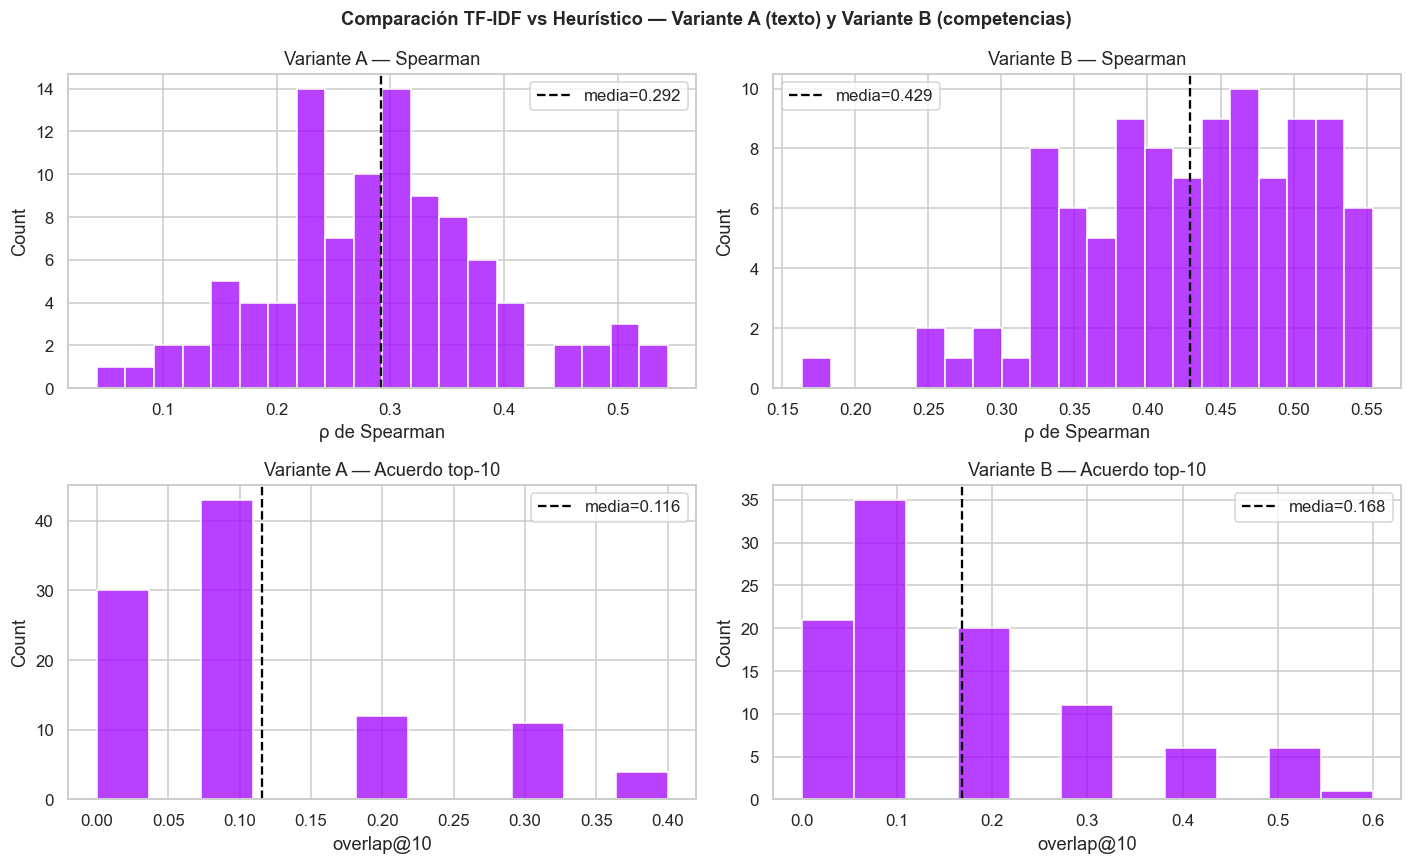

In [5]:
def overlap_at_k(a_scores, b_scores, k):
    top_a = set(np.argsort(-a_scores)[:k])
    top_b = set(np.argsort(-b_scores)[:k])
    return len(top_a & top_b) / k

def distinct_scores(scores):
    return len(np.unique(np.round(scores, 6)))

rows = []
for a, cid in enumerate(cand_ids):
    h = H_global[a]
    tA = TFIDF[a]       # Variante A: texto completo
    tB = TFIDF_comp[a]  # Variante B: competencias (título+área+tags)
    rhoA, _ = spearmanr(tA, h)
    rhoB, _ = spearmanr(tB, h)
    rows.append({
        "candidate_id": cid,
        "spearman_varA": rhoA,
        "overlap@1_varA": overlap_at_k(tA, h, 1),
        "overlap@5_varA": overlap_at_k(tA, h, 5),
        "overlap@10_varA": overlap_at_k(tA, h, 10),
        "spearman_varB": rhoB,
        "overlap@1_varB": overlap_at_k(tB, h, 1),
        "overlap@5_varB": overlap_at_k(tB, h, 5),
        "overlap@10_varB": overlap_at_k(tB, h, 10),
        "n_scores_distintos_heuristico": distinct_scores(h),
        "n_scores_distintos_tfidfA": distinct_scores(tA),
        "n_scores_distintos_tfidfB": distinct_scores(tB),
        "heuristico_constante": bool(np.unique(h).size == 1),
    })
comp = pd.DataFrame(rows)
comp.to_csv(CLEAN / "model2_ranking_comparison.csv", index=False, encoding="utf-8-sig")

validA = comp[~comp["spearman_varA"].isna()]
validB = comp[~comp["spearman_varB"].isna()]
n_const = int(comp["heuristico_constante"].sum())

print(f"Candidatos: {len(comp)} | con ranking heurístico constante (Spearman indefinido): {n_const}")
print()
print("── Variante A (texto completo: candidato_skills vs description_full) ──")
print(f"  Spearman  media={validA['spearman_varA'].mean():.4f}  mediana={validA['spearman_varA'].median():.4f}")
print(f"  Acuerdo top-1={comp['overlap@1_varA'].mean():.3f}  top-5={comp['overlap@5_varA'].mean():.3f}  top-10={comp['overlap@10_varA'].mean():.3f}")
print()
print("── Variante B (competencias: candidato_skills vs título+área+must/nice/tech) ──")
print(f"  Spearman  media={validB['spearman_varB'].mean():.4f}  mediana={validB['spearman_varB'].median():.4f}")
print(f"  Acuerdo top-1={comp['overlap@1_varB'].mean():.3f}  top-5={comp['overlap@5_varB'].mean():.3f}  top-10={comp['overlap@10_varB'].mean():.3f}")
print()
print(f"Scores distintos/candidato (media): heurístico={comp['n_scores_distintos_heuristico'].mean():.1f}  "
      f"TF-IDF comp={comp['n_scores_distintos_tfidfB'].mean():.1f}  TF-IDF texto={comp['n_scores_distintos_tfidfA'].mean():.1f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Comparación TF-IDF vs Heurístico — Variante A (texto) y Variante B (competencias)",
             fontsize=12, fontweight="bold")

for ax, col, label in [
    (axes[0,0], "spearman_varA", "Variante A — Spearman"),
    (axes[0,1], "spearman_varB", "Variante B — Spearman"),
]:
    valid = comp[~comp[col].isna()]
    sns.histplot(valid[col], bins=20, ax=ax, color=ACCENT)
    ax.axvline(valid[col].mean(), ls="--", color="black",
               label=f"media={valid[col].mean():.3f}")
    ax.set_title(label); ax.set_xlabel("ρ de Spearman"); ax.legend()

for ax, col, label in [
    (axes[1,0], "overlap@10_varA", "Variante A — Acuerdo top-10"),
    (axes[1,1], "overlap@10_varB", "Variante B — Acuerdo top-10"),
]:
    sns.histplot(comp[col], bins=11, ax=ax, color=ACCENT)
    ax.axvline(comp[col].mean(), ls="--", color="black",
               label=f"media={comp[col].mean():.3f}")
    ax.set_title(label); ax.set_xlabel("overlap@10"); ax.legend()

plt.tight_layout()
plt.savefig(FIG / "03_tfidf_vs_heuristico.png", bbox_inches="tight")
plt.show()

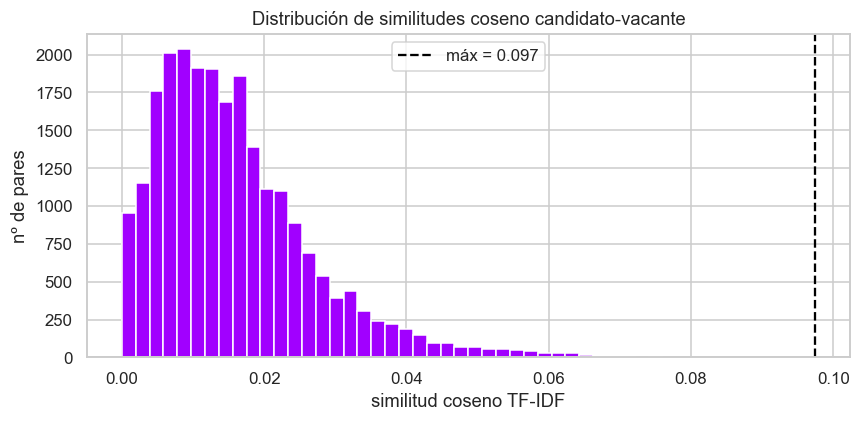

Similitud coseno TF-IDF -> media=0.0159  mediana=0.0137  máx=0.0974


In [6]:
# [añadido] Distribución de TODAS las similitudes coseno (matriz TFIDF aplanada)
_vals = TFIDF.ravel()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_vals, bins=50, color=ACCENT)
ax.axvline(_vals.max(), ls="--", color="black", label=f"máx = {_vals.max():.3f}")
ax.set_title("Distribución de similitudes coseno candidato-vacante")
ax.set_xlabel("similitud coseno TF-IDF"); ax.set_ylabel("nº de pares"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "03_hist_cosine.png", bbox_inches="tight"); plt.show()

# [añadido] valores numéricos (para citar en la memoria)
print(f"Similitud coseno TF-IDF -> media={_vals.mean():.4f}  mediana={np.median(_vals):.4f}  máx={_vals.max():.4f}")

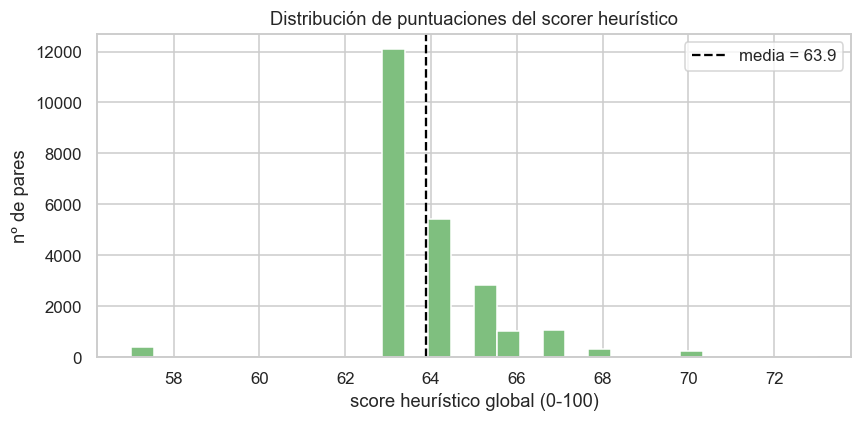

Score heurístico global -> min=57  máx=73  media=63.9


In [7]:
# [añadido] Distribución de los scores del heurístico global (H_global aplanado)
_h = H_global.ravel()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(_h, bins=30, color="#7fbf7f")
ax.axvline(_h.mean(), ls="--", color="black", label=f"media = {_h.mean():.1f}")
ax.set_title("Distribución de puntuaciones del scorer heurístico")
ax.set_xlabel("score heurístico global (0-100)"); ax.set_ylabel("nº de pares"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "03_hist_heuristico.png", bbox_inches="tight"); plt.show()

# [añadido] valores numéricos (para citar en la memoria)
print(f"Score heurístico global -> min={_h.min():.0f}  máx={_h.max():.0f}  media={_h.mean():.1f}")

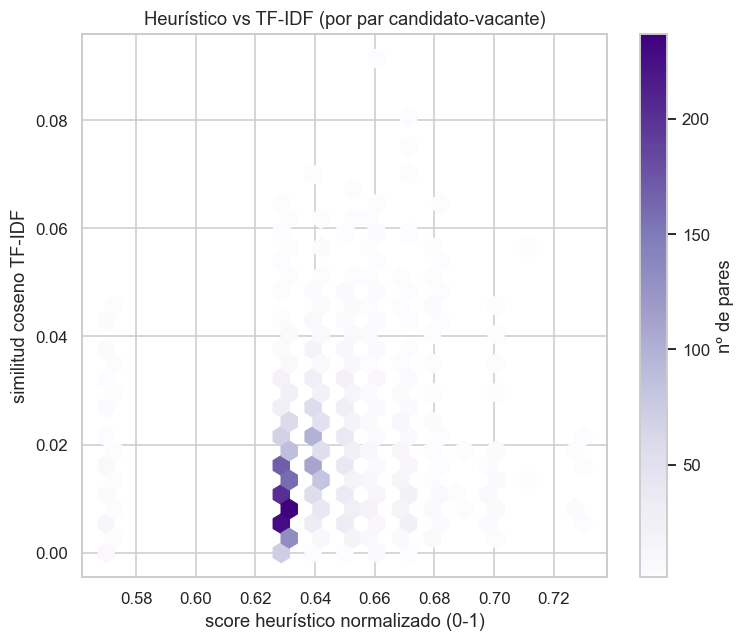

Correlación global heurístico vs TF-IDF (Pearson, 23600 pares): 0.203


In [8]:
# [añadido] Relación heurístico vs TF-IDF (muestra aleatoria de pares candidato-vacante)
_rng = np.random.default_rng(42)
_nc, _nj = TFIDF.shape
_ci = _rng.integers(0, _nc, 3000); _ji = _rng.integers(0, _nj, 3000)
_x = H_global[_ci, _ji] / 100.0
_y = TFIDF[_ci, _ji]
fig, ax = plt.subplots(figsize=(7, 6))
_hb = ax.hexbin(_x, _y, gridsize=30, cmap="Purples", mincnt=1)
fig.colorbar(_hb, label="nº de pares")
ax.set_title("Heurístico vs TF-IDF (por par candidato-vacante)")
ax.set_xlabel("score heurístico normalizado (0-1)"); ax.set_ylabel("similitud coseno TF-IDF")
plt.tight_layout(); plt.savefig(FIG / "03_heuristico_vs_tfidf.png", bbox_inches="tight"); plt.show()

# [añadido] valores numéricos (para citar en la memoria)
_corr = np.corrcoef(H_global.ravel() / 100.0, TFIDF.ravel())[0, 1]
print(f"Correlación global heurístico vs TF-IDF (Pearson, {H_global.size} pares): {_corr:.3f}")

## 4. ¿Dónde difieren? — un caso ilustrativo

In [9]:
# Elegimos un candidato con bastantes skills y ranking heurístico NO constante
cand_n_skills = {cid: len(cand_skills[cid]) for cid in cand_ids}
candidates_sorted = sorted(
    [r["candidate_id"] for _, r in comp[~comp["heuristico_constante"]].iterrows()],
    key=lambda c: cand_n_skills[c], reverse=True,
)
cid = candidates_sorted[0]
a = cand_ids.index(cid)

def top_jobs(scores, k=5):
    idx = np.argsort(-scores)[:k]
    return [(job_ids[b], round(float(scores[b]), 3)) for b in idx]

print(f"Candidato {cid} — skills: {', '.join(sorted(cand_skills[cid]))}\n")
top_h = top_jobs(H_global[a]); top_t = top_jobs(TFIDF[a])
print("TOP-5 HEURÍSTICO (global):")
for jid, sc in top_h:
    print(f"  job {jid:3d}  score={sc:>5}  {str(vac_by_id.loc[jid]['title'])[:60]}")
print("\nTOP-5 TF-IDF (cosine):")
for jid, sc in top_t:
    print(f"  job {jid:3d}  sim={sc:>5}  {str(vac_by_id.loc[jid]['title'])[:60]}")

# Una vacante que TF-IDF sube y el heurístico no tiene en su top-5
only_tfidf = [jid for jid, _ in top_t if jid not in {j for j, _ in top_h}]
if only_tfidf:
    jid = only_tfidf[0]
    desc = str(vac_by_id.loc[jid]["description_full"]).lower()
    nice = job_nice[jid]
    in_text = sorted([s for s in cand_skills[cid] if s in desc])
    print(f"\nVacante {jid} ('{str(vac_by_id.loc[jid]['title'])[:50]}') la sube TF-IDF pero no el heurístico.")
    print(f"  Skills del candidato presentes en el TEXTO de la oferta: {in_text}")
    print(f"  De esas, en los TAGS (tech/soft/lang) que ve el heurístico: {sorted(set(in_text) & nice)}")
    print("  => TF-IDF aprovecha skills citadas en la prosa que no están en los tags extraídos.")

Candidato 3 — skills: adaptabilidad, atención al detalle, capacidad analítica, estadística, excel avanzado, git, machine learning, numpy, power bi, proactividad, r, resolución de problemas, spark, sql, tableau, trabajo en equipo

TOP-5 HEURÍSTICO (global):
  job 204  score= 71.0  Retail - Mozo
  job 205  score= 71.0  Retail - Mozo
  job 193  score= 68.0  Caroll - Dependiente de tienda
  job 190  score= 68.0  Exact Forestall - Inspector de Calidad
  job 203  score= 68.0  Retail - Mozo

TOP-5 TF-IDF (cosine):
  job  35  sim=0.063  Programador IA (inteligencia artificial)
  job 203  sim=0.056  Retail - Mozo
  job 202  sim=0.056  Retail - Mozo
  job 204  sim=0.056  Retail - Mozo
  job 201  sim=0.056  Retail - Mozo

Vacante 35 ('Programador IA (inteligencia artificial)') la sube TF-IDF pero no el heurístico.
  Skills del candidato presentes en el TEXTO de la oferta: ['capacidad analítica', 'estadística', 'machine learning', 'proactividad', 'r']
  De esas, en los TAGS (tech/soft/lang) que ve

In [10]:
# [añadido] Dos casos ilustrativos más (candidates_sorted[1] y [2]) — misma lógica, solo salida impresa
for _cid in candidates_sorted[1:3]:
    _a = cand_ids.index(_cid)
    print()
    print(f"=== Candidato {_cid} — skills: {', '.join(sorted(cand_skills[_cid]))} ===")
    _th = top_jobs(H_global[_a]); _tt = top_jobs(TFIDF[_a])
    print("TOP-5 HEURÍSTICO (global):")
    for jid, sc in _th:
        print(f"  job {jid:3d}  score={sc:>5}  {str(vac_by_id.loc[jid]['title'])[:60]}")
    print("TOP-5 TF-IDF (cosine):")
    for jid, sc in _tt:
        print(f"  job {jid:3d}  sim={sc:>5}  {str(vac_by_id.loc[jid]['title'])[:60]}")


=== Candidato 19 — skills: capacidad analítica, comunicación, data warehouse, docker, excel avanzado, git, numpy, orientación a resultados, pandas, pensamiento crítico, power bi, resolución de problemas, spark, sql, tableau, trabajo en equipo ===
TOP-5 HEURÍSTICO (global):
  job  29  score= 70.0  Lider de Equipo IA
  job 120  score= 70.0  PROMOTOR/A TECNOLÓGICO – GAFAS DE IA MURCIA
  job 122  score= 70.0  Promotor/a tecnológico – Gafas IA LUGONES- SIERO
  job  70  score= 70.0  Promotor/a tecnológico - Gafas IA Mallorca
  job 125  score= 70.0  Promotor/a tecnológico – Gafas IA MÁLAGA OCTUBRE
TOP-5 TF-IDF (cosine):
  job 160  sim=0.052  Prácticas Despliegue de IA y mejora en procesos en Ingenierí
  job 213  sim=0.051  Especialista en Inteligencia Artificial y Automatización
  job 115  sim=0.048  Desarrollador Junior Agentes Virtuales IA Y RPA
  job 206  sim=0.045  Analista De Datos E Inteligencia Artificial - Zaragoza Prese
  job 161  sim=0.042  Arquitecto de Data Azure | Diseño de solu

## 5. Interpretación y honestidad

- **Qué se compara realmente:** TF-IDF (texto completo de la oferta vs skills del candidato) frente al
  **`skills_fit`** del heurístico (overlap exacto con `tech_stack ∪ soft_skills ∪ languages`). `values_fit`
  y `team_fit` son constantes (60) en estos datos → **no es un matching de producción completo**.
- **Spearman / top-k** (valores impresos arriba): miden cuánto coincide el orden de vacantes por candidato.
  Un acuerdo parcial es lo esperable: ambos usan señal de skills, pero TF-IDF añade el texto de la oferta.
- **Dónde aporta TF-IDF:** recupera vacantes cuya **descripción** menciona competencias del candidato aunque
  no figuren en los *tags* (sección 4), y suaviza el problema de que muchos `skills_fit` empatan (p.ej. 70).
- **Limitaciones:** TF-IDF es léxico (no semántico: no une sinónimos ni idiomas); el heurístico está
  capado y con stubs. Ninguno incorpora cultura/valores reales.

## 6. Hallazgos clave
- El ranking heurístico vivo depende **solo de `skills_fit`** (los otros dos componentes son constantes).
- TF-IDF y heurístico **coinciden parcialmente** (ver Spearman y top-k impresos) — comparten la señal de
  skills, pero divergen porque TF-IDF usa la oferta completa.
- Resultado guardado en `data/clean/model2_ranking_comparison.csv`; figura en `notebooks/figures/03_tfidf_vs_heuristico.png`.